In [ ]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git
!pip3 install statsmodels

Original Euclidean Distance: 2.70
Smoothed Euclidean Distance (7-MA): 1.03


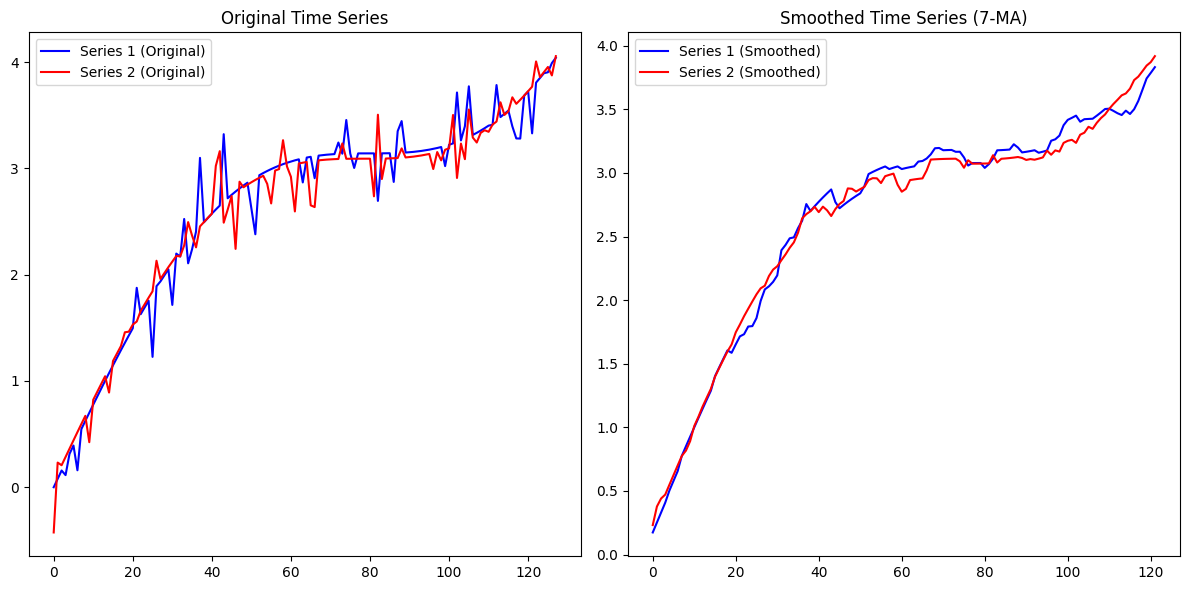

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sktime.transformations.series.moving_average import MovingAverageTransformer
from sktime.distances import euclidean_distance


def gen_noise(length, noise_probability=0.3):
    """Generate noise with some points having zero noise."""
    noise = np.random.normal(0, 0.3, length)
    random_mask = np.random.rand(length) > noise_probability
    noise[random_mask] = 0
    return noise


def generate_time_series(length=128):
    """Generate two similar but visually different time series with high Euclidean distance."""
    t = np.linspace(0, 10, length)
    series_1 = 0.5 * t + np.sin(0.5 * t) + gen_noise(length)
    series_2 = 0.5 * t + np.sin(0.5 * t + 0.05) + gen_noise(length)
    return series_1, series_2


def plot_series(original1, original2, smoothed1, smoothed2):
    """Plot the original and smoothed time series for comparison."""
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(original1, label="Series 1 (Original)", color='b')
    plt.plot(original2, label="Series 2 (Original)", color='r')
    plt.title("Original Time Series")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(smoothed1, label="Series 1 (Smoothed)", color='b')
    plt.plot(smoothed2, label="Series 2 (Smoothed)", color='r')
    plt.title("Smoothed Time Series (7-MA)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# 生成时间序列
series_1, series_2 = generate_time_series()

# 计算原始序列的欧氏距离 (sktime.distances 需要 2D 数组: n_samples x n_features)
original_distance = euclidean_distance(series_1.reshape(-1, 1), series_2.reshape(-1, 1))
print(f"Original Euclidean Distance: {original_distance:.2f}")

# 使用 MovingAverageTransformer 进行 7-MA 平滑
ma_transformer = MovingAverageTransformer(window_length=7, mode="valid")
smoothed_1 = ma_transformer.fit_transform(pd.Series(series_1)).values
smoothed_2 = ma_transformer.fit_transform(pd.Series(series_2)).values

# 计算平滑后的欧氏距离
smoothed_distance = euclidean_distance(smoothed_1.reshape(-1, 1), smoothed_2.reshape(-1, 1))
print(f"Smoothed Euclidean Distance (7-MA): {smoothed_distance:.2f}")

# 可视化
plot_series(series_1, series_2, smoothed_1, smoothed_2)
